In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

### Get File path and load the csv data

In [3]:
current_path = Path().cwd()
project_dir = current_path.parents[1]
data_path = project_dir / "data" / "data_processed"
file_path = data_path / "cassava" / "price_avg.csv"

wide = pd.read_csv(file_path)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [4]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

### Create a sequence dataset class for LSTM prediction

In [5]:
SEQ_LEN = 12
PRED_LEN = 12


class SeqDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        seq = self.data[idx : idx + self.seq_len]
        targ = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.from_numpy(seq).unsqueeze(-1), torch.from_numpy(targ)


In [6]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

### Create the LSTM regression model class

In [7]:
class LSTMRegressor(nn.Module):
    def __init__(self, hidden=32, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

### Training the LSTM model

In [8]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.00781
epoch 100/300  loss=0.00309
epoch 150/300  loss=0.00220
epoch 200/300  loss=0.00178
epoch 250/300  loss=0.00232
epoch 300/300  loss=0.00124


### Predict the data for the next year

In [9]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2024
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    3.47
2024-02-01    3.24
2024-03-01    3.12
2024-04-01    3.05
2024-05-01    2.99
2024-06-01    2.92
2024-07-01    2.86
2024-08-01    2.81
2024-09-01    2.76
2024-10-01    2.71
2024-11-01    2.67
2024-12-01    2.64
Freq: MS, Name: forecast_price, dtype: float64


In [10]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01    3.65            3.47
2024-02-01    3.65            3.24
2024-03-01    3.57            3.12
2024-04-01    3.24            3.05
2024-05-01    3.19            2.99
2024-06-01    3.09            2.92
2024-07-01    3.06            2.86
2024-08-01    2.95            2.81
2024-09-01    2.86            2.76
2024-10-01    2.65            2.71
2024-11-01    2.60            2.67
2024-12-01    2.32            2.64


### Compare The Error of a predicted data and the actual data in a table format

In [11]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = error.abs()
pct_error = (error / cmp["actual"]) * 100


print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "pct_error": pct_error,
    }
)
print(error_df.round(4))

average_percent_error = 0
for error_val in pct_error:
    average_percent_error += abs(error_val)

average_percent_error /= len(pct_error)
print(f"\n--- Average Percent Error: {average_percent_error:.2f}% ---")


--- Monthly Errors ---
            actual  forecast   error  abs_error  pct_error
2024-01-01    3.65    3.4651  0.1849     0.1849     5.0651
2024-02-01    3.65    3.2436  0.4064     0.4064    11.1342
2024-03-01    3.57    3.1168  0.4532     0.4532    12.6936
2024-04-01    3.24    3.0466  0.1934     0.1934     5.9697
2024-05-01    3.19    2.9852  0.2048     0.2048     6.4206
2024-06-01    3.09    2.9220  0.1680     0.1680     5.4371
2024-07-01    3.06    2.8621  0.1979     0.1979     6.4682
2024-08-01    2.95    2.8081  0.1419     0.1419     4.8094
2024-09-01    2.86    2.7594  0.1006     0.1006     3.5188
2024-10-01    2.65    2.7146 -0.0646     0.0646    -2.4392
2024-11-01    2.60    2.6734 -0.0734     0.0734    -2.8224
2024-12-01    2.32    2.6357 -0.3157     0.3157   -13.6064

--- Average Percent Error: 6.70% ---


### Plot The predicted data compare to an actual data

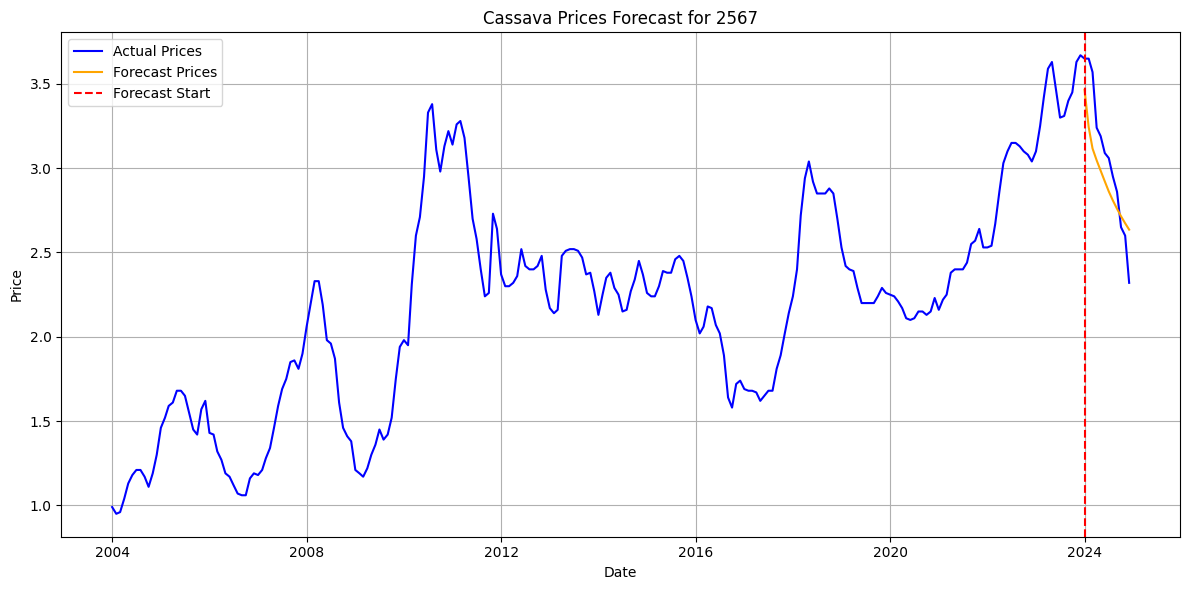

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title("Cassava Prices Forecast for 2567")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("cassava_prices_forecast.png")
plt.show()